In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv(r"car_purchasing.csv",encoding='latin')
data.head()

,customer name,customer e-mail,country,gender,age,annual Salary,credit card debt,net worth,car purchase amount
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,Bulgaria,0,41.851720,62812.09301,11609.380910,238961.2505,35321.45877
1,Harlan Barnes,eu.dolor@diam.co.uk,Belize,0,40.870623,66646.89292,9572.957136,530973.9078,45115.52566
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,Algeria,1,43.152897,53798.55112,11160.355060,638467.1773,42925.70921
3,Jade Cunningham,malesuada@dignissim.com,Cook Islands,1,58.271369,79370.03798,14426.164850,548599.0524,67422.36313
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,Brazil,1,57.313749,59729.15130,5358.712177,560304.0671,55915.46248


In [5]:
data.describe()

,gender,age,annual Salary,credit card debt,net worth,car purchase amount
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.506000,46.241674,62127.239608,9607.645049,431475.713625,44209.799218
std,0.500465,7.978862,11703.378228,3489.187973,173536.756340,10773.178744
min,0.000000,20.000000,20000.000000,100.000000,20000.000000,9000.000000
25%,0.000000,40.949969,54391.977195,7397.515792,299824.195900,37629.896040
50%,1.000000,46.049901,62915.497035,9655.035568,426750.120650,43997.783390
75%,1.000000,51.612263,70117.862005,11798.867487,557324.478725,51254.709517
max,1.000000,70.000000,100000.000000,20000.000000,1000000.000000,80000.000000


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer name        500 non-null    str    
 1   customer e-mail      500 non-null    str    
 2   country              500 non-null    str    
 3   gender               500 non-null    int64  
 4   age                  500 non-null    float64
 5   annual Salary        500 non-null    float64
 6   credit card debt     500 non-null    float64
 7   net worth            500 non-null    float64
 8   car purchase amount  500 non-null    float64
dtypes: float64(5), int64(1), str(3)
memory usage: 60.0 KB


In [8]:
data.columns

Index(['customer name', 'customer e-mail', 'country', 'gender', 'age',
       'annual Salary', 'credit card debt', 'net worth',
       'car purchase amount'],
      dtype='str')

In [9]:
data.isna().sum()

customer name          0
customer e-mail        0
country                0
gender                 0
age                    0
annual Salary          0
credit card debt       0
net worth              0
car purchase amount    0
dtype: int64

In [10]:
# rename some columns
col_to_rename={
    'customer name':'customer_name', 
    'customer e-mail':'customer_email', 
     'annual Salary':'annual_salary', 
    'credit card debt':'credit_card_debt', 
    'net worth':'net_worth',
       'car purchase amount':'car_value'
}
data.rename(columns = col_to_rename, inplace=True)

In [11]:
data.columns

Index(['customer_name', 'customer_email', 'country', 'gender', 'age',
       'annual_salary', 'credit_card_debt', 'net_worth', 'car_value'],
      dtype='str')

In [12]:
# drop columns, 'customer_name', 'customer_email'
data.drop(columns=['customer_name','customer_email'], inplace=True)

In [14]:
data.head(2)

,country,gender,age,annual_salary,credit_card_debt,net_worth,car_value
0,Bulgaria,0,41.851720,62812.09301,11609.380910,238961.2505,35321.45877
1,Belize,0,40.870623,66646.89292,9572.957136,530973.9078,45115.52566


In [16]:
# encoding: 'gender' column -- do manual encoding
enc_gender = {1:'Male',0:'Female'}
data['gender']= data['gender'].map(enc_gender)
data.head()

,country,gender,age,annual_salary,credit_card_debt,net_worth,car_value
0,Bulgaria,Female,41.851720,62812.09301,11609.380910,238961.2505,35321.45877
1,Belize,Female,40.870623,66646.89292,9572.957136,530973.9078,45115.52566
2,Algeria,Male,43.152897,53798.55112,11160.355060,638467.1773,42925.70921
3,Cook Islands,Male,58.271369,79370.03798,14426.164850,548599.0524,67422.36313
4,Brazil,Male,57.313749,59729.15130,5358.712177,560304.0671,55915.46248


In [23]:
# Age should be integer not a float
data['age'] = data['age'].astype('int')
data.head(3)

,country,gender,age,annual_salary,credit_card_debt,net_worth,car_value
0,Bulgaria,Female,41,62812.09301,11609.380910,238961.2505,35321.45877
1,Belize,Female,40,66646.89292,9572.957136,530973.9078,45115.52566
2,Algeria,Male,43,53798.55112,11160.355060,638467.1773,42925.70921


In [24]:
# data analysis

In [25]:
data.describe()

,age,annual_salary,credit_card_debt,net_worth,car_value
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,45.774000,62127.239608,9607.645049,431475.713625,44209.799218
std,7.988652,11703.378228,3489.187973,173536.756340,10773.178744
min,20.000000,20000.000000,100.000000,20000.000000,9000.000000
25%,40.000000,54391.977195,7397.515792,299824.195900,37629.896040
50%,46.000000,62915.497035,9655.035568,426750.120650,43997.783390
75%,51.000000,70117.862005,11798.867487,557324.478725,51254.709517
max,70.000000,100000.000000,20000.000000,1000000.000000,80000.000000


In [28]:
net_worth = data.groupby('gender')['net_worth'].mean()
net_worth

gender
Female    432948.721130
Male      430037.639104
Name: net_worth, dtype: float64

In [33]:
print(f"The mean net worth of Male is {round (net_worth['Male'],2)}")
print(f"The mean net worth of Female is {net_worth['Female']:.2f}")
print(f"The difference is {net_worth['Female'] - net_worth['Male']:.2f}")

The mean net worth of Male is 430037.64
The mean net worth of Female is 432948.72
The difference is 2911.08


In [34]:
car_value = data.groupby('gender')['car_value'].mean()
car_value

gender
Female    44933.131928
Male      43503.620644
Name: car_value, dtype: float64

In [36]:
mean_age = data.groupby('gender')['age'].mean()
mean_age

gender
Female    46.283401
Male      45.276680
Name: age, dtype: float64

In [37]:
data.groupby('gender')['credit_card_debt'].mean()

gender
Female    9522.298721
Male      9690.967353
Name: credit_card_debt, dtype: float64

In [38]:
data.groupby('gender')['annual_salary'].mean()

gender
Female    62559.128313
Male      61705.593322
Name: annual_salary, dtype: float64

<Axes: xlabel='age'>

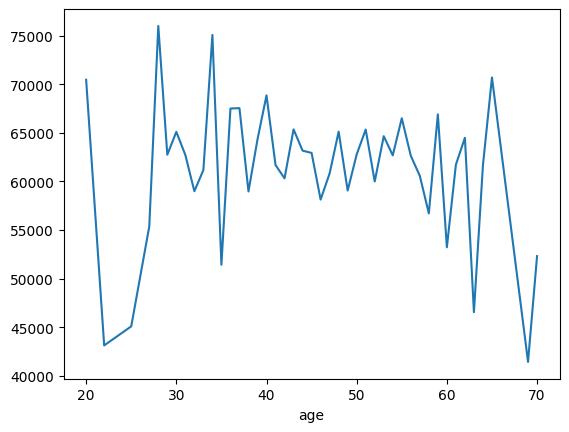

In [42]:
# How does age affect annual earnings ?
data.groupby('age')['annual_salary'].median().plot(kind='line')

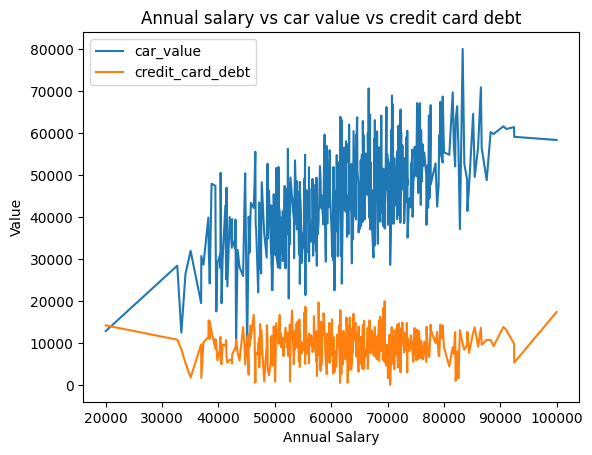

In [49]:
# What is the relative credit card debt to car value based on annual income?
annual_salary_car_value = data.groupby('annual_salary')[['car_value','credit_card_debt']].mean()
plt.plot(annual_salary_car_value)
plt.legend(['car_value','credit_card_debt'])
plt.xlabel('Annual Salary')
plt.ylabel('Value')
plt.title('Annual salary vs car value vs credit card debt')
plt.show()

In [50]:
annual_salary_car_value

,car_value,credit_card_debt
annual_salary,,
20000.00000,12895.71468,14261.807730
32697.98161,28463.64326,10858.025260
33422.99683,12536.93842,8570.611562
34154.77654,26499.31418,5316.010491
35069.41886,31978.97990,1851.979839
...,...,...
90556.62686,61593.52058,13872.566700
91083.73918,60960.83428,13148.855970
92455.72807,61404.22578,9877.169366


In [52]:
salary_30_40k = annual_salary_car_value[(annual_salary_car_value.index > 30000) & (annual_salary_car_value.index < 40000)]
salary_30_40k

,car_value,credit_card_debt
annual_salary,,
32697.98161,28463.64326,10858.025260
33422.99683,12536.93842,8570.611562
34154.77654,26499.31418,5316.010491
35069.41886,31978.97990,1851.979839
36929.35124,19553.27390,9719.192898
36960.76994,30736.57980,1768.874438
37336.33830,28700.03340,10218.320920
38213.88844,39892.93343,11492.741740
38284.02013,31696.99679,15467.787450


In [56]:
print(f"The ratio of car value to credit cared debt is {(salary_30_40k['car_value'].mean() / salary_30_40k['credit_card_debt'].mean()):.2f}")

The ratio of car value to credit cared debt is 3.22


In [58]:
salary_40_50k = annual_salary_car_value[(annual_salary_car_value.index > 40000) & (annual_salary_car_value.index < 50000)]
salary_40_50k

,car_value,credit_card_debt
annual_salary,,
40300.49467,31146.71078,8828.164449
40346.06491,27889.95197,11505.899060
40387.92070,50539.90169,5761.401538
40558.75456,19525.29827,4981.269146
40727.39196,29556.79320,9725.549901
41236.36497,42773.75905,9399.342975
41361.95045,25252.93221,10755.508420
41409.29390,42139.64528,8211.340920
41434.51258,47009.57741,6810.555606


In [59]:
print(f"The ratio of car value to credit card debt is {(salary_40_50k['car_value'].mean() / salary_40_50k['credit_card_debt'].mean()):.2f}")

The ratio of car value to credit card debt is 4.13


In [60]:
salary_60_70k = annual_salary_car_value[(annual_salary_car_value.index > 60000) & (annual_salary_car_value.index < 70000)]
salary_60_70k

,car_value,credit_card_debt
annual_salary,,
60101.79725,35823.55471,12989.367840
60174.05765,30667.60927,15666.431550
60181.40633,37883.24231,7094.896557
60325.20676,29754.66271,10128.115100
60380.22868,39975.43302,2799.719601
...,...,...
69506.62127,42384.05128,5449.471997
69612.01230,45078.40193,8125.598993
69810.46265,66158.69494,4684.556433


In [61]:
print(f"The ratio of car value to credit card debt is {(salary_60_70k['car_value'].mean() / salary_60_70k['credit_card_debt'].mean()):.2f}")

The ratio of car value to credit card debt is 4.69


In [62]:
salary_80_90k = annual_salary_car_value[(annual_salary_car_value.index > 80000) & (annual_salary_car_value.index < 90000)]
salary_80_90k

,car_value,credit_card_debt
annual_salary,,
80015.83115,55420.56668,9064.618618
80959.53310,54823.19221,4499.921096
81565.95967,69669.47402,9072.063059
81757.66856,57430.76903,7500.778414
81997.33071,52056.41478,12616.456220
82094.10712,63248.76188,1065.607589
82358.22683,66363.89316,8092.475103
82425.64679,63038.20422,7525.252104
82573.01132,57306.32866,1696.989764


In [63]:
print(f"The ratio of car value to credit card debt is {(salary_80_90k['car_value'].mean() / salary_80_90k['credit_card_debt'].mean()):.2f}")

The ratio of car value to credit card debt is 6.19


In [70]:
ratio_list = [round(salary_30_40k['car_value'].mean() / salary_30_40k['credit_card_debt'].mean(),2),
             round(salary_40_50k['car_value'].mean() / salary_40_50k['credit_card_debt'].mean(),2),
              round(salary_60_70k['car_value'].mean() / salary_60_70k['credit_card_debt'].mean(),2),
              round(salary_80_90k['car_value'].mean() / salary_80_90k['credit_card_debt'].mean(),2),
             
             ]

In [71]:
ratio_list

[np.float64(3.22), np.float64(4.13), np.float64(4.69), np.float64(6.19)]

<BarContainer object of 4 artists>

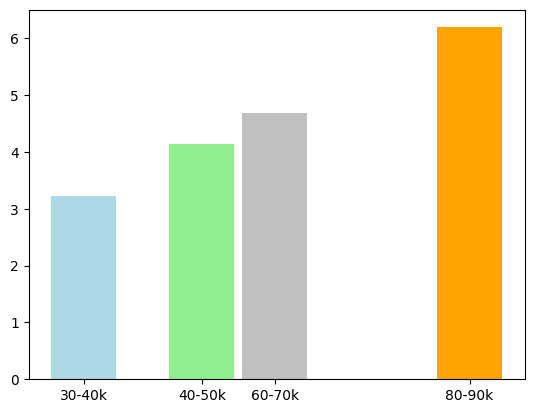

In [74]:
plt.bar(ratio_list, height=[ratio_list[0],ratio_list[1],ratio_list[2],ratio_list[3]], tick_label=['30-40k', '40-50k', '60-70k', '80-90k'], color=['lightblue', 'lightgreen', 'silver', 'orange'], width=0.5)

In [75]:
# Conclusion -> What is the relative credit card debt to car value based on annual income?
# the value of car increases as salary increases. whereas credit card debt doesnot follow the same trend
# the ratio of car value to credit card debt is defined by 4 salary ranges (30 -40, 40 -50 , 60-70, 80-90)
#  the ratio are : 30-40K is (3.22),40-50k is (4.13),60-70k is (4.69),80-90k is (6.19)
# It shows that as the salary increases the ratio of car value to credit card debt also increases 


In [76]:
# Is there a correlation between net wealth and car value?
data[['net_worth','car_value']].corr()

,net_worth,car_value
net_worth,1.00000,0.48858
car_value,0.48858,1.00000


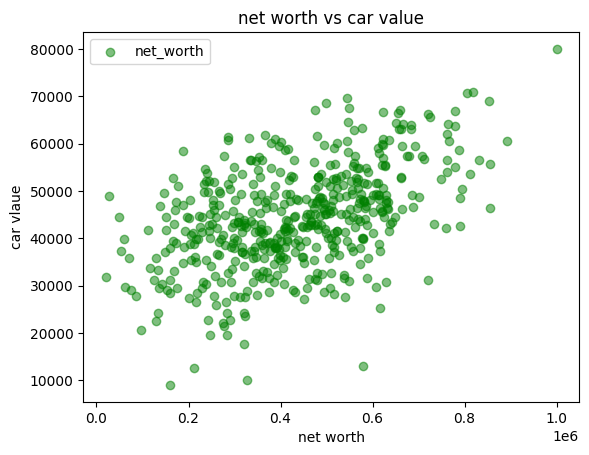

In [84]:
plt.scatter(data['net_worth'], data['car_value'], alpha=0.5, color='green')
plt.legend(['net_worth','car_value'])
plt.title("net worth vs car value")
plt.xlabel('net worth')
plt.ylabel('car vlaue')
plt.show()

<Axes: >

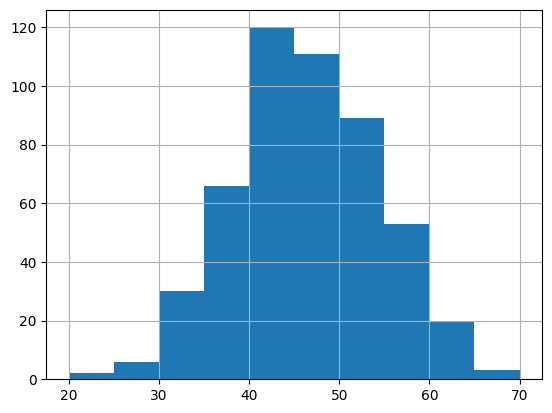

In [85]:
# What percentage of annual income is credit card debt for different age groups?
data.age.hist()

array([[<Axes: title={'center': 'car_value'}>,
        <Axes: title={'center': 'age'}>]], dtype=object)

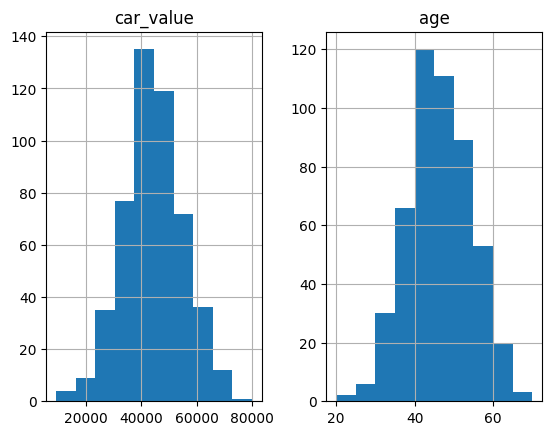

In [86]:
# Is there a correlation between age and car value?
data[['car_value','age']].hist()

In [87]:
data[['car_value','age']].corr()

,car_value,age
car_value,1.000000,0.631192
age,0.631192,1.000000


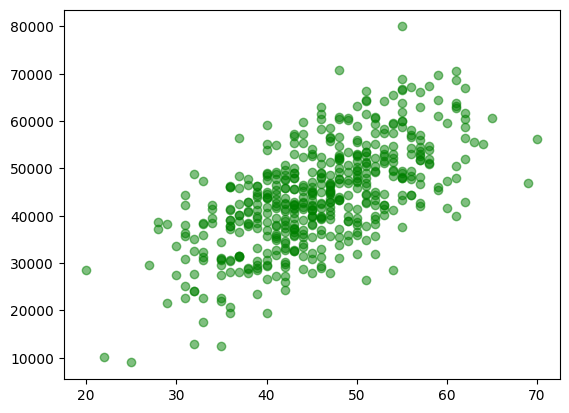

In [88]:
plt.scatter(data['age'], data['car_value'], alpha=0.5, color='green')


In [89]:
from sklearn.model_selection import train_test_split

X = data[['age']]
y = data['car_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

X_train.shape, X_test.shape

((425, 1), (75, 1))

In [90]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[848.74]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['age']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5181
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [91]:
y_pred = model.predict(X_test)

y_pred

array([35735.87267913, 45072.03621105, 53559.45760371, 47618.26262885,
       45920.77835032, 56954.42616077, 42525.80979326, 51013.23118591,
       53559.45760371, 45920.77835032, 41677.06765399, 64593.10541416,
       52710.71546444, 35735.87267913, 38282.09909693, 39130.84123619,
       39979.58337546, 33189.64626134, 44223.29407179, 45920.77835032,
       43374.55193252, 47618.26262885, 45920.77835032, 43374.55193252,
       50164.48904664, 37433.35695766, 50164.48904664, 47618.26262885,
       34887.13053987, 45920.77835032, 49315.74690738, 47618.26262885,
       38282.09909693, 51013.23118591, 41677.06765399, 43374.55193252,
       57803.16830003, 43374.55193252, 49315.74690738, 50164.48904664,
       42525.80979326, 46769.52048958, 56105.6840215 , 36584.6148184 ,
       48467.00476811, 52710.71546444, 39979.58337546, 50164.48904664,
       45920.77835032, 43374.55193252, 39130.84123619, 32340.90412207,
       43374.55193252, 46769.52048958, 43374.55193252, 53559.45760371,
      

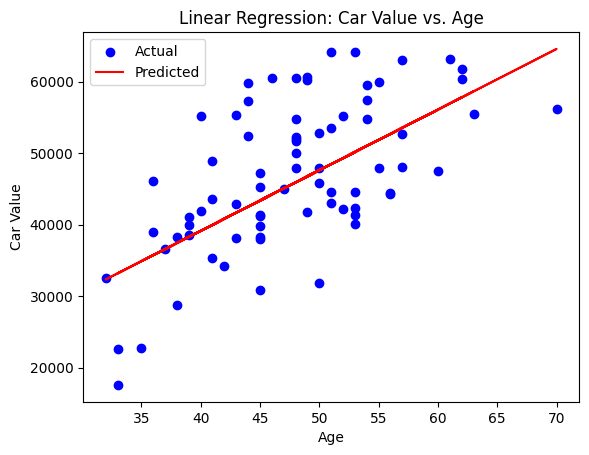

In [97]:
plt.scatter(X_test,y_test, color='blue', label='Actual')
plt.plot(X_test,y_pred, color='red', label='Predicted')
plt.title('Linear Regression: Car Value vs. Age')
plt.xlabel('Age')
plt.ylabel('Car Value')
plt.legend()
plt.show()

In [98]:
# Conclusion -> Is there a correlation between age and car value?
# from the linear regression, we see some occurances of car value increases as age increse
# but still not clear correlation between age and car value.

In [116]:
# KNN Model - Predicting Annual Income¶
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [125]:
X = data[['credit_card_debt', 'net_worth', 'car_value']]
y = data['annual_salary']

label_encoder = LabelEncoder()
X.loc[:,'credit_card_debt'] = label_encoder.fit_transform(X['credit_card_debt'])
X.loc[:,'net_worth'] = label_encoder.fit_transform(X['net_worth'])
X.loc[:,'car_value'] = label_encoder.fit_transform(X['car_value'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

print("R-squared:", r2_score(y_test, y_pred))

Mean Squared Error: 82218802.74825004
Root Mean Squared Error: 9067.45845031837
R-squared: 0.30154807628330016


In [126]:
print(list(y_test[:10]))

[74420.10254, 59139.2108, 67752.38329, 55381.53225, 63975.0609, 61824.8798, 63305.84963, 60991.82443, 48716.67271, 65850.47688]


In [127]:
print(y_pred[:10])

[66518.393356 65943.643934 75535.357548 58998.023176 70850.456192
 63209.98174  62386.86399  68835.792984 58373.065714 60711.427788]


In [128]:
print(y_test[:10] - y_pred[:10])

361    7901.709184
73    -6804.433134
374   -7782.974258
155   -3616.490926
104   -6875.395292
394   -1385.101940
377     918.985640
124   -7843.968554
68    -9656.393004
450    5139.049092
Name: annual_salary, dtype: float64


In [129]:
X.head()

,credit_card_debt,net_worth,car_value
0,366.0,70.0,92.0
1,241.0,350.0,272.0
2,336.0,450.0,232.0
3,461.0,365.0,493.0
4,56.0,376.0,429.0


In [130]:
y.head()

0    62812.09301
1    66646.89292
2    53798.55112
3    79370.03798
4    59729.15130
Name: annual_salary, dtype: float64

In [131]:
data.head()

,country,gender,age,annual_salary,credit_card_debt,net_worth,car_value
0,Bulgaria,Female,41,62812.09301,11609.380910,238961.2505,35321.45877
1,Belize,Female,40,66646.89292,9572.957136,530973.9078,45115.52566
2,Algeria,Male,43,53798.55112,11160.355060,638467.1773,42925.70921
3,Cook Islands,Male,58,79370.03798,14426.164850,548599.0524,67422.36313
4,Brazil,Male,57,59729.15130,5358.712177,560304.0671,55915.46248
